In [4]:
# Import required libraries
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import json
import zipfile
import urllib.request

# Import PerceptionMetrics components
from perceptionmetrics.datasets.coco import CocoDataset
from perceptionmetrics.models.torch_detection import TorchImageDetectionModel

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [5]:
# Create directories for data
os.makedirs("local/data/models", exist_ok=True)
os.makedirs("local/outputs", exist_ok=True)

In [ ]:
# ---- Choose your dataset mode ----
USE_SMALL_SUBSET = True   # Set to False to download the full val2017 dataset
SUBSET_SIZE = 20          # Number of images to use if USE_SMALL_SUBSET is True
# -----------------------------------

os.makedirs("local/data/coco", exist_ok=True)
os.makedirs("local/data/coco/val2017", exist_ok=True)

ann_zip_path = "local/data/coco/annotations.zip"
ann_dir = "local/data/coco/annotations"

if not os.path.exists(ann_dir):
    print("Downloading annotations (~250MB)...")
    urllib.request.urlretrieve(
        "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
        ann_zip_path
    )
    print("Extracting annotations...")
    with zipfile.ZipFile(ann_zip_path, 'r') as z:
        z.extractall("local/data/coco")
    print("Done.")

ann_file = f"{ann_dir}/instances_val2017.json"

if USE_SMALL_SUBSET:
    print(f"Using a small subset of {SUBSET_SIZE} images...")

    with open(ann_file, "r") as f:
        coco_data = json.load(f)

    subset_images = coco_data["images"][:SUBSET_SIZE]
    subset_image_ids = {img["id"] for img in subset_images}

    for img in subset_images:
        fname = img["file_name"]
        local_path = f"local/data/coco/val2017/{fname}"
        if not os.path.exists(local_path):
            url = f"http://images.cocodataset.org/val2017/{fname}"
            urllib.request.urlretrieve(url, local_path)
    print(f"Downloaded {len(subset_images)} images.")

    subset_annotations = [a for a in coco_data["annotations"] if a["image_id"] in subset_image_ids]
    subset_coco = {
        "images": subset_images,
        "annotations": subset_annotations,
        "categories": coco_data["categories"]
    }
    subset_ann_file = "local/data/coco/annotations/instances_val2017_subset.json"
    with open(subset_ann_file, "w") as f:
        json.dump(subset_coco, f)

    ann_file = subset_ann_file
    print("Subset ready.")

else:
    img_zip_path = "local/data/coco/val2017.zip"
    if not os.path.exists("local/data/coco/val2017") or len(os.listdir("local/data/coco/val2017")) == 0:
        print("Downloading full val2017 images (~1GB)...")
        urllib.request.urlretrieve("http://images.cocodataset.org/zips/val2017.zip", img_zip_path)
        print("Extracting images...")
        with zipfile.ZipFile(img_zip_path, 'r') as z:
            z.extractall("local/data/coco")
        print("Done.")

img_dir = "local/data/coco/val2017"
print(f"\nReady. img_dir={img_dir}, ann_file={ann_file}")

In [ ]:
# Initialize COCO dataset

dataset = None

if not os.path.exists(img_dir) or not os.path.exists(ann_file):
    print("COCO data not found. Please check that both paths exist on your machine.")
else:
    try:
        dataset = CocoDataset(annotation_file=ann_file, image_dir=img_dir, split="train")
        print(f"Dataset loaded with {len(dataset.dataset)} samples")
        print(f"Number of classes: {len(dataset.ontology)}")
    except Exception as e:
        print(f"Failed to load COCO dataset: {e}")

In [ ]:
# Create a pre-trained detection model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

# Save the model
model_path = "local/data/models/maskrcnn_model.pt"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
torch.save(model, model_path)
model_cfg = {
    "batch_size": 1,
    "num_workers": 0,
    "confidence_threshold": 0.8,
    "nms_threshold": 0.3
}
config_path = "local/data/models/maskrcnn_config.json"
with open(config_path, "w") as f:
    json.dump(model_cfg, f, indent=2)


ontology_path = "local/data/models/coco_model_ontology.json"
with open(ontology_path, "w") as f:
    json.dump(dataset.ontology, f, indent=2)

print("Model and configuration saved!")

In [14]:
detection_model = TorchImageDetectionModel(
    model=model_path,
    model_cfg=config_path,
    ontology_fname=ontology_path,  # This is the model ontology (indices as keys)
    device="cuda"
)


print("Detection model initialized!")

'resize_cfg' missing in model config. No resizing will be applied.
Detection model initialized!


In [16]:
# Function to visualize detection results
def visualize_detections(image, predictions, ground_truth=None, title="Detection Results"):
    """Visualize detection predictions and optionally ground truth."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Display image
    ax.imshow(image)

    #map labels to class names
    label_to_name = {v['idx'] : k for k, v in dataset.ontology.items()}

    # Draw prediction boxes
    if predictions and isinstance(predictions, dict) and 'boxes' in predictions:
        boxes = predictions['boxes'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy()
        labels = predictions['labels'].cpu().numpy()

        for i, (box, score, category_idx) in enumerate(zip(boxes, scores, labels)):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            class_name = label_to_name.get(category_idx, str(category_idx))

            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
            )
            ax.add_patch(rect)

            ax.text(x1, y1-5, f'{class_name}: {score:.2f}',
                   color='red', fontsize=10, weight='bold')

    if ground_truth and isinstance(ground_truth, tuple) and len(ground_truth) >= 2:
        gt_boxes, gt_category_indices = ground_truth

        for _, (box, category_idx) in enumerate(zip(gt_boxes, gt_category_indices)):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            class_name = label_to_name.get(category_idx, str(category_idx))

            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor='green', facecolor='none', alpha=0.7
            )
            ax.add_patch(rect)

            ax.text(x1, y1+height+5, f'GT: {class_name}',
                   color='green', fontsize=10, weight='bold')

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

 Testing inference on: /home/sally/PerceptionMetrics/examples/local/data/coco/val2017/000000037777.jpg
 Found 12 detections
 Ground truth: 14 objects


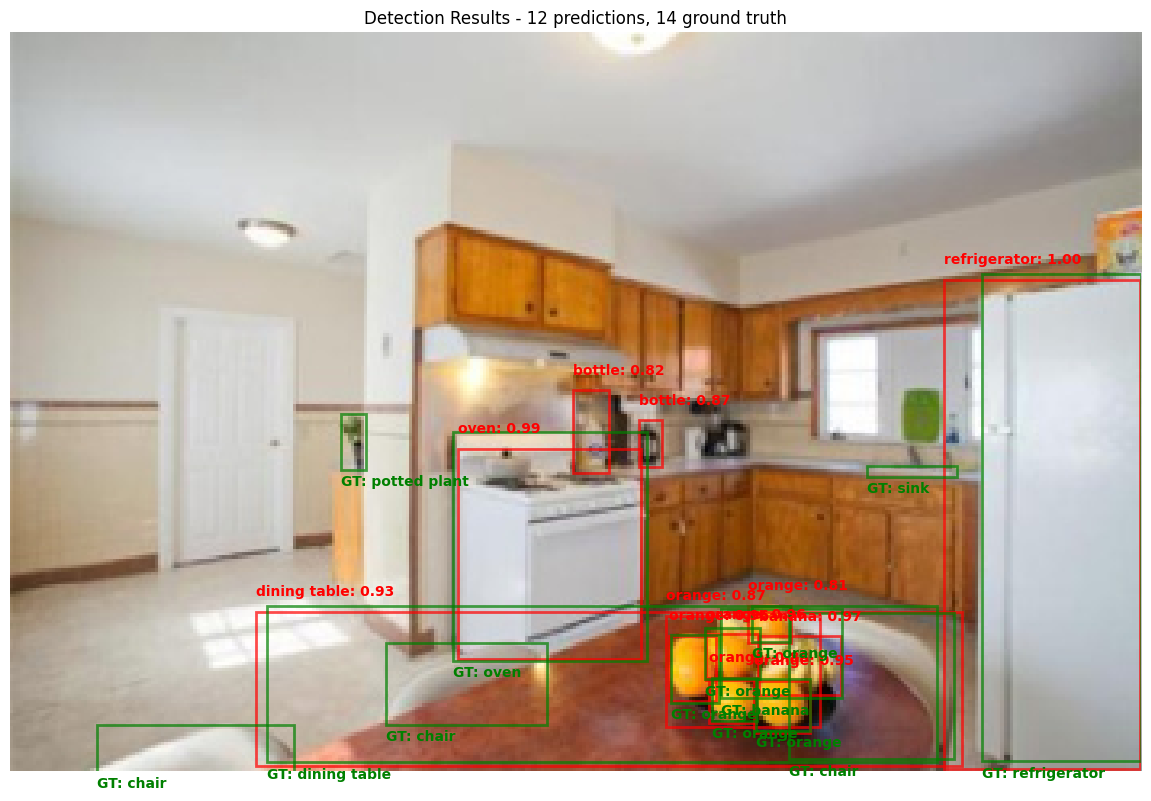

In [17]:
# Test inference on a single image
if 'dataset' in locals() and dataset is not None:
    dataset.make_fname_global()

    sample_idx = 1
    image_path = dataset.dataset.iloc[sample_idx]['image']

    image = Image.open(image_path).convert('RGB')
    print(f" Testing inference on: {image_path}")
    predictions = detection_model.predict(image)

    print(f" Found {len(predictions['boxes'])} detections")
    annotation_path = dataset.dataset.iloc[sample_idx]['annotation']
    ground_truth = dataset.read_annotation(annotation_path)

    print(f" Ground truth: {len(ground_truth[0])} objects")
    visualize_detections(
        np.array(image),
        predictions,
        ground_truth,
        title=f"Detection Results - {len(predictions['boxes'])} predictions, {len(ground_truth[0])} ground truth"
    )
else:
    print(" Dataset not loaded. Please check the data paths above.")

In [ ]:
# Run evaluation on a subset of the dataset
if 'dataset' in locals():

    small_dataset = dataset.dataset
    small_dataset = dataset.dataset.iloc[10:15]

    original_dataset = dataset.dataset
    dataset.dataset = small_dataset

    predictions_outdir = "local/outputs/detection_preds"
    os.makedirs(predictions_outdir, exist_ok=True)

    try:
        results = detection_model.eval(
            dataset=dataset,
            split="train",
            predictions_outdir=predictions_outdir,
            results_per_sample=True
        )

        print(" Evaluation completed!")

    except Exception as e:
        print(f" Evaluation failed: {e}")
        import traceback
        traceback.print_exc()

    finally:
        dataset.dataset = original_dataset
        dataset.dataset_dir = None
else:
    print("  Dataset not loaded. Please check the data paths above.")

  0%|          | 0/5 [00:00<?, ?it/s]

 Evaluation completed!



Metrics DataFrame:


,person,bicycle,car,motorcycle,airplane,bus,train,truck,boat,traffic light,...,sink,refrigerator,book,clock,vase,scissors,teddy bear,hair drier,toothbrush,mean
AP,0.870130,0.0,0.272727,0.636364,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,0.106294,NaN,1.000000,NaN,NaN,NaN,NaN,0.428731
Precision,0.928571,0.0,0.500000,1.000000,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,0.294118,NaN,0.666667,NaN,NaN,NaN,NaN,0.559290
Recall,0.928571,0.0,0.250000,0.666667,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,0.217391,NaN,1.000000,NaN,NaN,NaN,NaN,0.430842
TP,13.000000,0.0,1.000000,2.000000,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,5.000000,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000
FP,1.000000,0.0,1.000000,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,12.000000,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000
FN,1.000000,1.0,3.000000,1.000000,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,18.000000,NaN,0.000000,NaN,NaN,NaN,NaN,2.466667
mAP@[0.5:0.95],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.313439
AUC-PR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318661


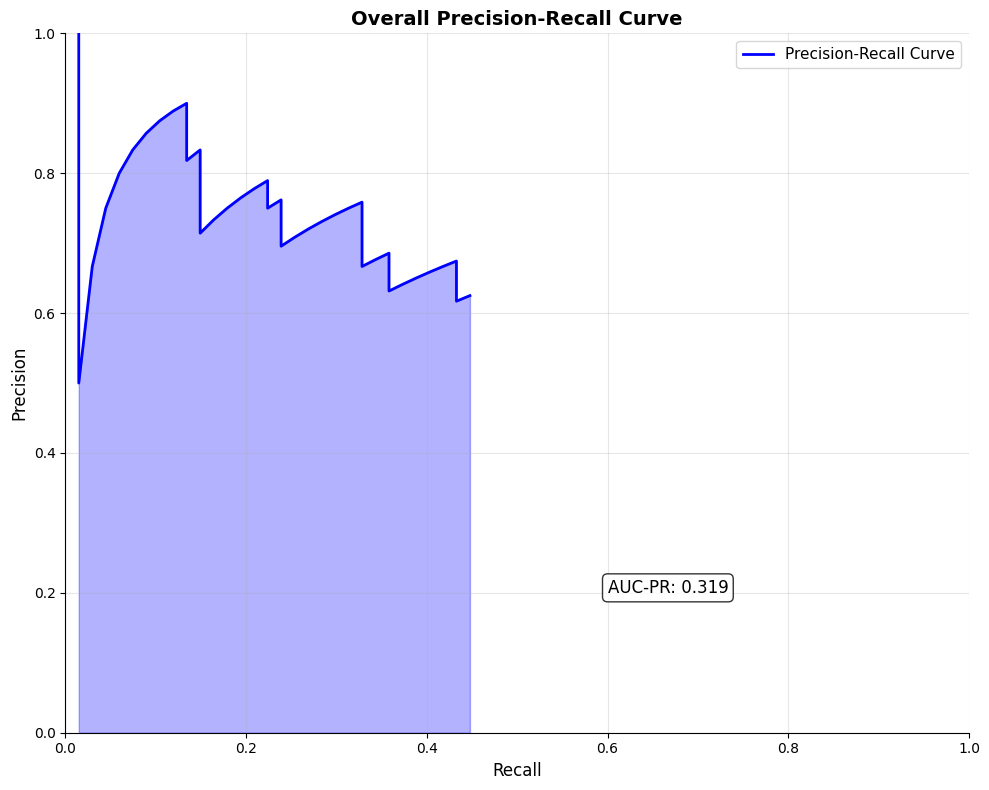

Precision-Recall Curve plotted with AUC-PR: 0.319


In [19]:
# Visualize Precision-Recall Curve
import matplotlib.pyplot as plt

if isinstance(results, dict):
    metrics_df = results["metrics_df"]
    metrics_factory = results["metrics_factory"]
else:
    metrics_df = results
    metrics_factory = None

print("\nMetrics DataFrame:")
display(metrics_df)

if metrics_factory is not None:
    curve_data = metrics_factory.get_overall_precision_recall_curve()
    auc_pr = metrics_factory.compute_auc_pr()

    plt.figure(figsize=(10, 8))

    plt.plot(curve_data['recall'], curve_data['precision'],
             linewidth=2, color='blue', label=f'Precision-Recall Curve')

    plt.fill_between(curve_data['recall'], curve_data['precision'],
                     alpha=0.3, color='blue')

    plt.text(0.6, 0.2, f'AUC-PR: {auc_pr:.3f}',
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Overall Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    plt.xlim([0, 1])
    plt.ylim([0, 1])

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f"Precision-Recall Curve plotted with AUC-PR: {auc_pr:.3f}")

else:
    print("Precision-recall curve data not available.")
    print("The evaluation results don't contain the metrics factory object.")

    if hasattr(metrics_df, 'index') and 'AP' in metrics_df.index:
        print("\nAvailable metrics:")
        for metric in metrics_df.index:
            if metric in ['AP', 'mAP@[0.5:0.95]', 'AUC-PR']:
                mean_value = metrics_df.loc[metric, 'mean']
                print(f"{metric}: {mean_value:.3f}")